In [99]:
# imports
import importlib
import models.hybrid_v2
import models.hybrid_v1
import models.hybrid_v3
import utils.plotting
importlib.reload(models.hybrid_v2)
importlib.reload(models.hybrid_v1)
importlib.reload(models.hybrid_v3)
importlib.reload(utils.plotting)

<module 'utils.plotting' from 'c:\\Users\\ARKA ROY\\Downloads\\option price project\\utils\\plotting.py'>

In [100]:
import pandas as pd
import numpy as np

from utils.bs import bs_call
from utils.features import *
from utils.evaluation import *
from utils.losses import *  
from models.hybrid_v3 import HybridNetV3

import torch.optim as optim


In [95]:
# load data
df = pd.read_csv("AsianPaints_Model_Data_2023_25.csv")

# PREPROCESSING 

In [96]:
# =========================
# DATA CLEANING + FEATURES
# =========================

import numpy as np
from utils.features import compute_greeks

eps = 1e-6
split_date = "2025-05-01"

# --- Basic cleaning
df = df.copy()
df = df.replace([np.inf, -np.inf], np.nan)

# --- Apply BS price
df["bs_price"] = df.apply(
    lambda row: bs_call(
        row["S"], row["K"], row["T"],
        row["r"], row["sigma"]
    ), axis=1
)

# --- Error (optional but useful for plots later)
df["error"] = df["Market_Price"] - df["bs_price"]

# --- Core features
df["log_moneyness"] = np.log(df["S"] / df["K"])
df["sqrt_T"] = np.sqrt(df["T"])
df["sigma_sqrt_T"] = df["sigma"] * df["sqrt_T"]

# --- Filters (important)
df = df[(df["Market_Price"] > 5) & (df["bs_price"] > 5)]
df = df[(df["T"] > 0.05) & (df["T"] < 0.5)]
df = df[(df["log_moneyness"] > -0.3) & (df["log_moneyness"] < 0.3)]

# --- Greeks
df = compute_greeks(df)

# --- Derived features
df["vix_ratio"] = df["sigma"] / (df["vix"] + eps)
df["time_vol"] = df["sigma"] * np.sqrt(df["T"])
df["vega_scaled"] = df["vega"] / (df["Market_Price"] + eps)

# --- Final cleanup
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# --- Sort by time
df = df.sort_values("Date").reset_index(drop=True)

features = [
    "log_moneyness", "T", "sqrt_T",
    "sigma", "sigma_sqrt_T", "vix", "vol_ma",
    "delta", "gamma", "vega", "theta",
    "vix_ratio", "time_vol","vega_scaled"
]

In [97]:
from sklearn.preprocessing import StandardScaler

import torch
# TRAIN SPLIT
train_df = df[df["Date"] < split_date].copy()

# SCALING (FIT ONLY ON TRAIN)

scaler = StandardScaler()

X_train = scaler.fit_transform(train_df[features])
X_full = scaler.transform(df[features])

y_train = train_df["Market_Price"].values
bs_train = train_df["bs_price"].values

bs_full = df["bs_price"].values

# TENSORS
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
bs_train = torch.tensor(bs_train, dtype=torch.float32)

X_full = torch.tensor(X_full, dtype=torch.float32)
bs_full = torch.tensor(bs_full, dtype=torch.float32)

# MODEL FITTING

In [102]:
sigma_index = features.index("sigma")

model = HybridNetV3(input_dim=len(features), sigma_index=sigma_index)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
batch_size = 1024

for epoch in range(epochs):
    model.train()
    
    perm = torch.randperm(X_train.size(0))
    total_loss = 0
    
    for i in range(0, X_train.size(0), batch_size):
        idx = perm[i:i+batch_size]
        
        xb = X_train[idx]
        yb = y_train[idx]
        bsb = bs_train[idx]
        
        optimizer.zero_grad()
        
        hybrid, alpha, log_error = model(xb, bsb)
        
        loss = custom_loss(hybrid, yb, alpha, log_error, bsb)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch} | Loss: {total_loss:.4f}")

Epoch 0 | Loss: 23517.5269
Epoch 5 | Loss: 1333.3953
Epoch 10 | Loss: 816.1025
Epoch 15 | Loss: 1352.3997
Epoch 20 | Loss: 609.1079
Epoch 25 | Loss: 680.0804
Epoch 30 | Loss: 700.3897
Epoch 35 | Loss: 449.5635
Epoch 40 | Loss: 387.9579
Epoch 45 | Loss: 382.2535


##### Fittig model to full data for plots

In [103]:
model.eval()

with torch.no_grad():
    hybrid_pred, alpha_pred, log_error_pred = model(X_full, bs_full)

# Convert to numpy
hybrid_pred = hybrid_pred.detach().cpu().numpy().flatten()
alpha_pred = alpha_pred.detach().cpu().numpy().flatten()
log_error_pred = log_error_pred.detach().cpu().numpy().flatten()

bs_np = bs_full.detach().cpu().numpy()

# ML price
ml_price = bs_np * np.exp(log_error_pred)

# Attach to df
df = df.copy()
df["ml_price"] = ml_price
df["alpha"] = alpha_pred
df["hybrid_price"] = hybrid_pred

# Errors
df["bs_error"] = df["Market_Price"] - df["bs_price"]
df["hybrid_error"] = df["Market_Price"] - df["hybrid_price"]


# VISUALIZATION

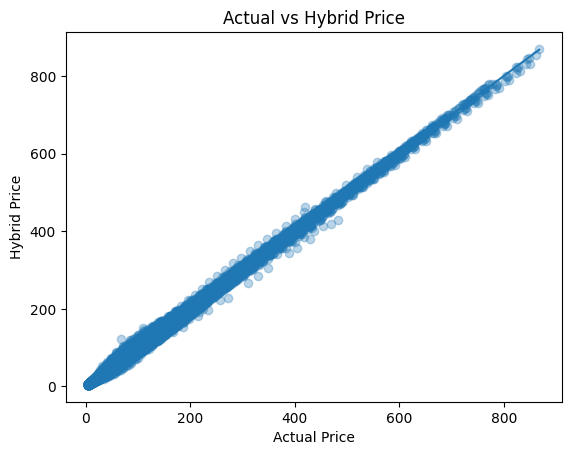

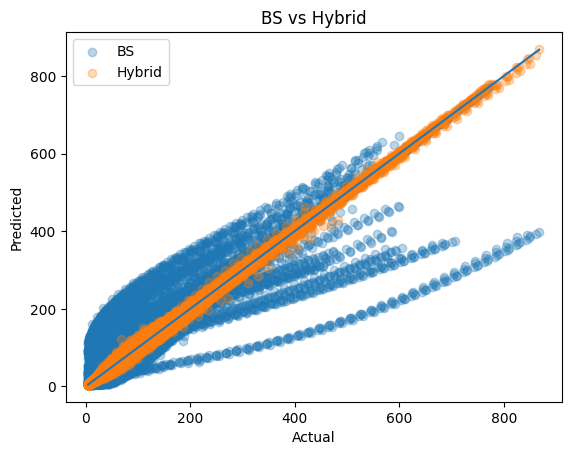

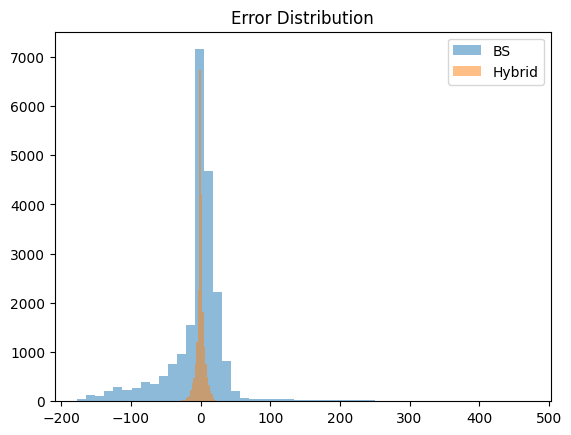

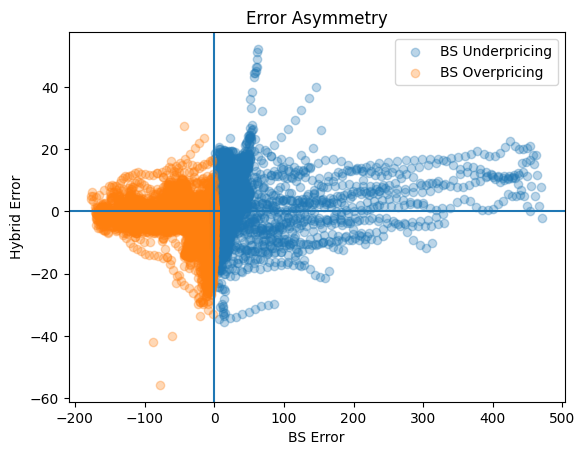

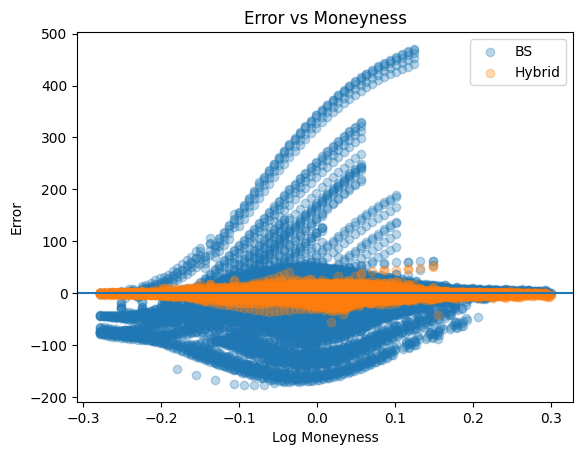

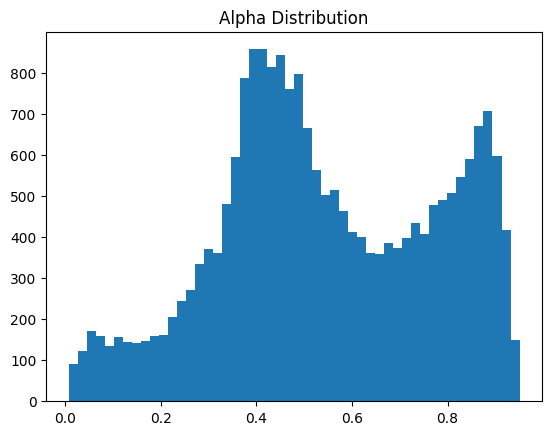

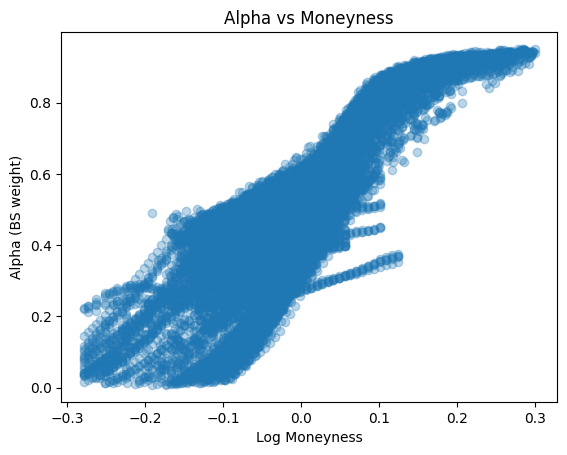

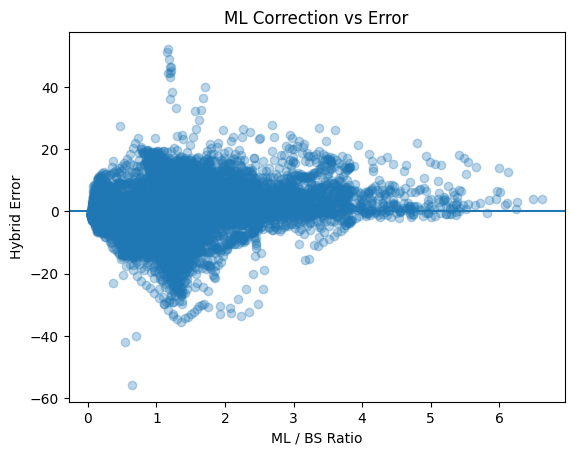

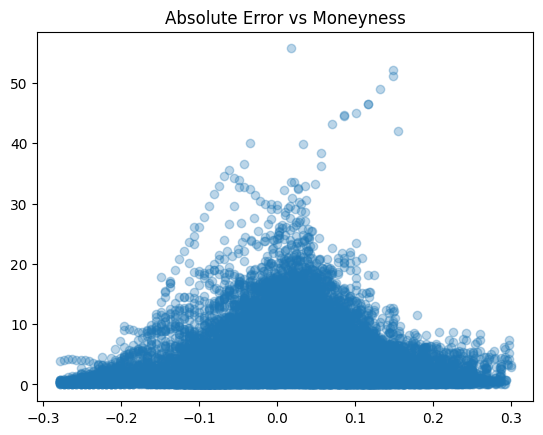

In [104]:
utils.plotting.plot_all(df)

# STRESS TESTING 

In [105]:
# evaluation
scenario_results = stress_scenarios(model, df, features, scaler)
regime_results = regime_test(model, df, features, scaler)
tail_results = tail_risk_analysis(model, df, features, scaler)

In [ ]:
pd.DataFrame(scenario_results).T

,hybrid_mean,hybrid_std,bs_mean,bs_std
base,164.534592,147.810715,167.729057,139.420902
low_vol,145.571854,145.362686,133.856211,145.363527
high_vol,264.662323,271.268463,256.699060,157.564592
deep_ITM,802.766785,187.575027,795.672104,173.695021
deep_OTM,13.039007,23.180521,9.790837,22.392730
near_expiry,122.517586,142.604675,116.954104,143.725986
market_crash,50.452675,97.366905,27.207486,43.207640


In [106]:
pd.DataFrame(scenario_results).T

,hybrid_mean,hybrid_std,bs_mean,bs_std
base,165.265060,148.535004,167.729057,139.420902
low_vol,144.890518,144.494522,133.856211,145.363527
high_vol,283.880768,289.207367,256.699060,157.564592
deep_ITM,798.173035,185.786209,795.672104,173.695021
deep_OTM,12.842429,23.565790,9.790837,22.392730
near_expiry,132.154434,145.439209,116.954104,143.725986
market_crash,42.146236,73.837296,27.207486,43.207640
